In [1]:
%pip install chembl_webresource_client rdkit scikit-learn chemprop pandas numpy matplotlib seaborn

  Using cached torch-2.10.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_bindings-12.9.4-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 

Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors

from chembl_webresource_client.new_client import new_client

print("All imports successful.")


All imports successful.


Fetch logBB data from ChEMBL

In [3]:
def fetch_logbb_data(max_records=2000):
    activity = new_client.activity
    results = activity.filter(
        standard_type="logBB",
        standard_relation="=",
        assay_type="A"
    ).only(["molecule_chembl_id", "canonical_smiles", "standard_value"])

    records = []
    for r in results[:max_records]:
        try:
            val = float(r["standard_value"])
            smi = r["canonical_smiles"]
            if smi and -5 < val < 5:
                records.append({
                    "chembl_id": r["molecule_chembl_id"],
                    "smiles": smi,
                    "logBB": val
                })
        except (TypeError, ValueError):
            continue

    df = pd.DataFrame(records).drop_duplicates(subset="smiles")
    return df

df = fetch_logbb_data(max_records=2000)
print(f"Retrieved {len(df)} valid compounds.")
df.head()

Retrieved 33 valid compounds.


,chembl_id,smiles,logBB
0,CHEMBL243571,CN(C)S(=O)(=O)c1ccc(-c2ccc3cc(O)ccc3c2Oc2ccc(O...,-0.37
1,CHEMBL244206,Oc1ccc2c(Oc3ccc(OCCN4CCCCC4)cc3)c(-c3ccc(F)c(F...,0.92
2,CHEMBL390021,Oc1ccc2c(Oc3ccc(OCCN4CCCCC4)cc3)c(-c3cccc(F)c3...,0.73
3,CHEMBL244205,Oc1ccc2c(Oc3ccc(OCCN4CCCCC4)cc3)c(-c3ccc(F)cc3...,1.25
4,CHEMBL244000,Oc1ccc(-c2ccc3cc(O)ccc3c2Oc2ccc(OCCN3CCCCC3)cc...,-0.77


EDA: logBB distribution

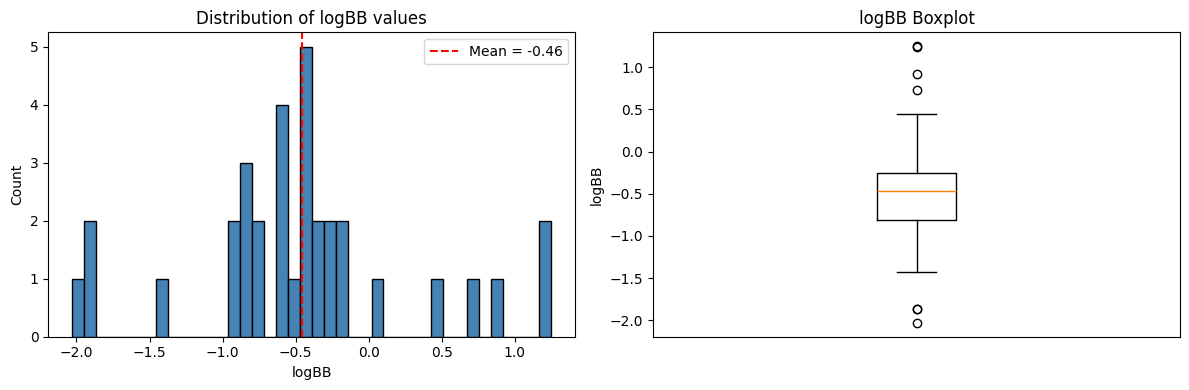

count    33.000000
mean     -0.458758
std       0.769852
min      -2.030000
25%      -0.810000
50%      -0.470000
75%      -0.250000
max       1.250000
Name: logBB, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["logBB"], bins=40, color="steelblue", edgecolor="k")
axes[0].axvline(df["logBB"].mean(), color="red", linestyle="--",
                label=f"Mean = {df['logBB'].mean():.2f}")
axes[0].set_xlabel("logBB")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of logBB values")
axes[0].legend()

axes[1].boxplot(df["logBB"])
axes[1].set_ylabel("logBB")
axes[1].set_title("logBB Boxplot")
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig("logBB_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(df["logBB"].describe())


Featurization (RDKit descriptors + Morgan fingerprints)

In [5]:
DESCRIPTOR_LIST = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors",
    "NumRotatableBonds", "NumAromaticRings", "RingCount",
    "FractionCSP3", "HeavyAtomCount"
]

def compute_descriptors(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * len(DESCRIPTOR_LIST))
        else:
            rows.append([getattr(Descriptors, d)(mol) for d in DESCRIPTOR_LIST])
    return pd.DataFrame(rows, columns=DESCRIPTOR_LIST)

def compute_morgan_fps(smiles_list, radius=2, n_bits=1024):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            fps.append(np.zeros(n_bits))
        else:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            arr = np.zeros(n_bits)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
    return pd.DataFrame(fps, columns=[f"Morgan_{i}" for i in range(n_bits)])

def featurize(df):
    desc = compute_descriptors(df["smiles"].tolist())
    fps  = compute_morgan_fps(df["smiles"].tolist())
    X    = pd.concat([desc, fps], axis=1)
    y    = df["logBB"].values
    valid = ~X.isnull().any(axis=1)
    return X[valid], y[valid], df[valid.values]

print("Featurization functions defined.")

Featurization functions defined.


Scaffold-based train/test split

In [6]:
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except Exception:
        return None

def scaffold_split(df, test_frac=0.2, seed=42):
    df = df.copy()
    df["scaffold"] = df["smiles"].apply(get_scaffold)
    groups = df.groupby("scaffold").apply(lambda x: list(x.index))
    group_list = list(groups.items())

    rng = np.random.RandomState(seed)
    rng.shuffle(group_list)

    n_test = int(len(df) * test_frac)
    test_idx, train_idx = [], []
    for _, idx_list in group_list:
        if len(test_idx) < n_test:
            test_idx.extend(idx_list)
        else:
            train_idx.extend(idx_list)

    return df.loc[train_idx], df.loc[test_idx]

train_df, test_df = scaffold_split(df, test_frac=0.2)
print(f"Scaffold split: {len(train_df)} train / {len(test_df)} test")

print("Computing features...")
X_train, y_train, train_df = featurize(train_df.reset_index(drop=True))
X_test,  y_test,  test_df  = featurize(test_df.reset_index(drop=True))
feature_names = list(X_train.columns)
print(f"Feature matrix: {X_train.shape[1]} features per compound")


Scaffold split: 27 train / 6 test
Computing features...
Feature matrix: 1034 features per compound


[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerator
[21:22:59] DEPRECATION WARNING: please use MorganGenerat

Noise floor estimation

In [7]:
def estimate_noise_floor(y, noise_std=0.3, n_sim=1000, seed=42):
    rng = np.random.RandomState(seed)
    rmse_list, r2_list = [], []
    for _ in range(n_sim):
        y_noisy = y + rng.normal(0, noise_std, size=len(y))
        rmse_list.append(np.sqrt(mean_squared_error(y, y_noisy)))
        r2_list.append(r2_score(y, y_noisy))
    return np.mean(rmse_list), np.mean(r2_list)

noise_rmse, noise_r2 = estimate_noise_floor(y_test, noise_std=0.3)
print(f"Noise floor estimate (assay σ = 0.3 log units):")
print(f"  RMSE floor : {noise_rmse:.3f}")
print(f"  R² ceiling : {noise_r2:.3f}")

Noise floor estimate (assay σ = 0.3 log units):
  RMSE floor : 0.288
  R² ceiling : 0.882


Train scikit-learn models

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "Model": name,
        "R²":    round(r2_score(y_te, y_pred), 3),
        "RMSE":  round(np.sqrt(mean_squared_error(y_te, y_pred)), 3),
        "MAE":   round(mean_absolute_error(y_te, y_pred), 3),
    }, y_pred

models = {
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_features=0.3,
                                               min_samples_leaf=3, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=42),
}

all_results, all_preds = [], {}
for name, mdl in models.items():
    m, y_pred = evaluate_model(mdl, X_train.values, y_train, X_test.values, y_test, name)
    all_results.append(m)
    all_preds[name] = y_pred
    print(f"{name:22s} | R²={m['R²']:.3f}  RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}")

results_df = pd.DataFrame(all_results)


Ridge Regression       | R²=-0.941  RMSE=1.216  MAE=0.992
Random Forest          | R²=-0.157  RMSE=0.939  MAE=0.630
Gradient Boosting      | R²=-0.328  RMSE=1.006  MAE=0.757


ChemProp (D-MPNN) via CLI

In [9]:
import os, subprocess, tempfile

def run_chemprop(train_df, test_df, target_col="logBB"):
    with tempfile.TemporaryDirectory() as tmpdir:
        train_path = os.path.join(tmpdir, "train.csv")
        test_path  = os.path.join(tmpdir, "test.csv")
        pred_path  = os.path.join(tmpdir, "preds.csv")
        model_dir  = os.path.join(tmpdir, "model")

        train_df[["smiles", target_col]].to_csv(train_path, index=False)
        test_df[["smiles", target_col]].to_csv(test_path, index=False)

        subprocess.run([
            "chemprop_train",
            "--data_path", train_path,
            "--dataset_type", "regression",
            "--target_columns", target_col,
            "--save_dir", model_dir,
            "--epochs", "30",
            "--batch_size", "32",
            "--quiet"
        ], check=True)

        subprocess.run([
            "chemprop_predict",
            "--test_path", test_path,
            "--checkpoint_dir", model_dir,
            "--preds_path", pred_path
        ], check=True)

        preds  = pd.read_csv(pred_path)
        y_pred = preds[target_col].values
        y_true = test_df[target_col].values

        return {
            "Model": "ChemProp (D-MPNN)",
            "R²":    round(r2_score(y_true, y_pred), 3),
            "RMSE":  round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
            "MAE":   round(mean_absolute_error(y_true, y_pred), 3),
        }, y_pred

try:
    cp_metrics, cp_preds = run_chemprop(train_df, test_df)
    all_results.append(cp_metrics)
    all_preds["ChemProp (D-MPNN)"] = cp_preds
    results_df = pd.DataFrame(all_results)
    print(f"ChemProp (D-MPNN)      | R²={cp_metrics['R²']:.3f}  RMSE={cp_metrics['RMSE']:.3f}  MAE={cp_metrics['MAE']:.3f}")
except Exception as e:
    print(f"ChemProp skipped: {e}")

Traceback (most recent call last):
  File "/home/s_kurup/miniconda3/envs/bio_ml/bin/chemprop_train", line 3, in <module>
    from chemprop.train import chemprop_train
  File "/home/s_kurup/miniconda3/envs/bio_ml/lib/python3.10/site-packages/chemprop/__init__.py", line 4, in <module>
    import chemprop.train
  File "/home/s_kurup/miniconda3/envs/bio_ml/lib/python3.10/site-packages/chemprop/train/__init__.py", line 5, in <module>
    from .cross_validate import chemprop_train, cross_validate, TRAIN_LOGGER_NAME
  File "/home/s_kurup/miniconda3/envs/bio_ml/lib/python3.10/site-packages/chemprop/train/cross_validate.py", line 13, in <module>
    from .run_training import run_training
  File "/home/s_kurup/miniconda3/envs/bio_ml/lib/python3.10/site-packages/chemprop/train/run_training.py", line 8, in <module>
    warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning) 
  File "/home/s_kurup/miniconda3/envs/bio_ml/lib/python3.10/site-packages/numpy/__init__.py", line 414, in 

ChemProp skipped: Command '['chemprop_train', '--data_path', '/tmp/tmpoe0idsfg/train.csv', '--dataset_type', 'regression', '--target_columns', 'logBB', '--save_dir', '/tmp/tmpoe0idsfg/model', '--epochs', '30', '--batch_size', '32', '--quiet']' returned non-zero exit status 1.


CELL 10 — Applicability domain (k-NN in fingerprint space)

In [10]:
morgan_cols = [c for c in feature_names if c.startswith("Morgan_")]
X_train_fp  = X_train[morgan_cols].values
X_test_fp   = X_test[morgan_cols].values

nn = NearestNeighbors(n_neighbors=5, metric="euclidean")
nn.fit(X_train_fp)
dists, _ = nn.kneighbors(X_test_fp)
avg_dist  = dists.mean(axis=1)

threshold = np.percentile(avg_dist, 95)
in_domain = avg_dist <= threshold

print(f"In-domain:   {in_domain.sum()} / {len(in_domain)} test compounds")
print(f"OOD flagged: {(~in_domain).sum()} compounds")


In-domain:   5 / 6 test compounds
OOD flagged: 1 compounds


Plot: Predicted vs. Actual (all models)

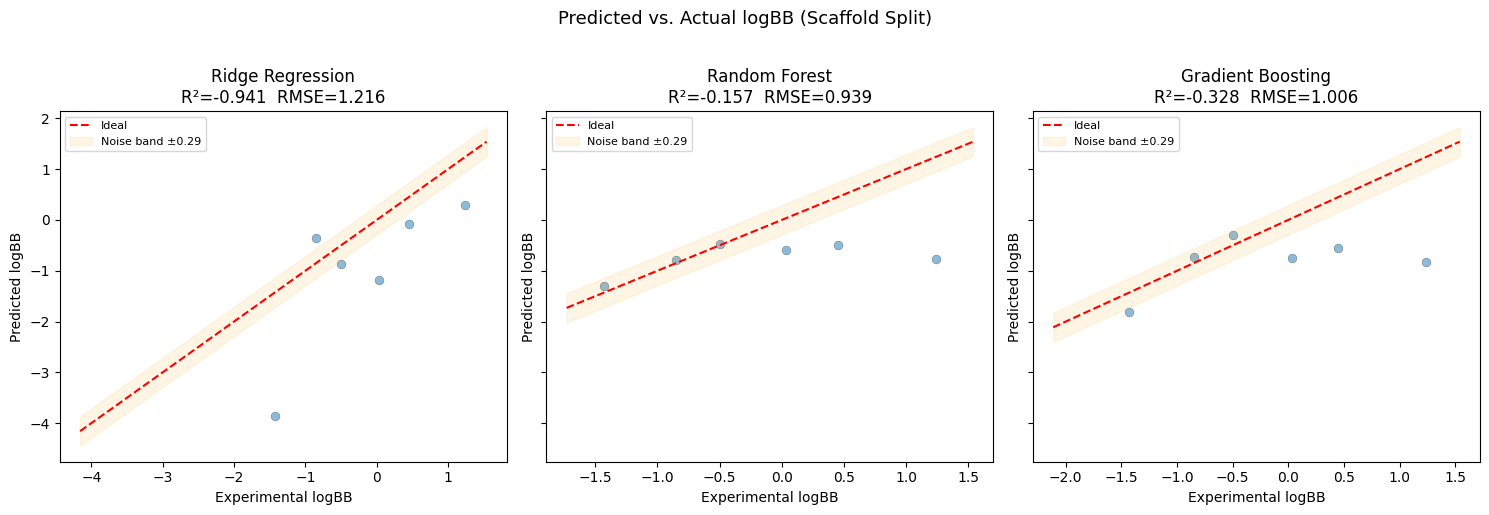

In [11]:
n = len(all_preds)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, all_preds.items()):
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    lo   = min(y_test.min(), y_pred.min()) - 0.3
    hi   = max(y_test.max(), y_pred.max()) + 0.3

    ax.scatter(y_test, y_pred, alpha=0.5, edgecolors="k", linewidths=0.3, s=40)
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    ax.fill_between([lo, hi],
                    [lo - noise_rmse, hi - noise_rmse],
                    [lo + noise_rmse, hi + noise_rmse],
                    alpha=0.1, color="orange", label=f"Noise band ±{noise_rmse:.2f}")
    ax.set_xlabel("Experimental logBB")
    ax.set_ylabel("Predicted logBB")
    ax.set_title(f"{name}\nR²={r2:.3f}  RMSE={rmse:.3f}")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs. Actual logBB (Scaffold Split)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


Plot: Model comparison vs. noise floor

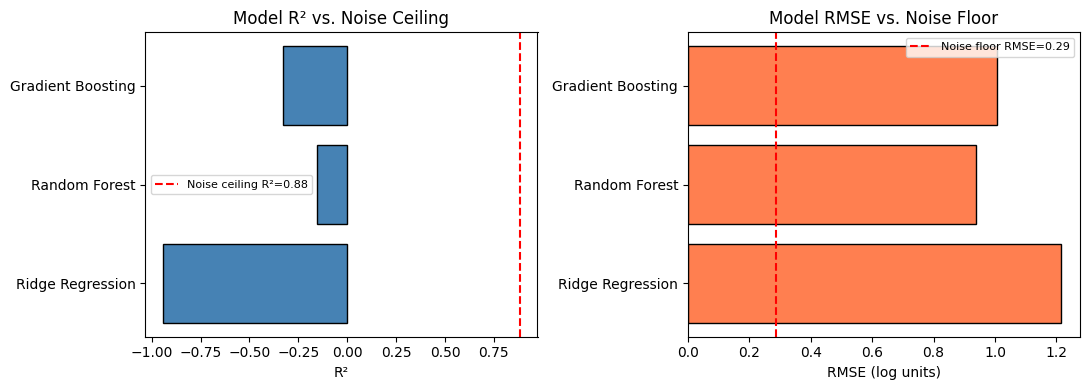

In [12]:
Fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(results_df["Model"], results_df["R²"], color="steelblue", edgecolor="k")
axes[0].axvline(noise_r2, color="red", linestyle="--",
                label=f"Noise ceiling R²={noise_r2:.2f}")
axes[0].set_xlabel("R²")
axes[0].set_title("Model R² vs. Noise Ceiling")
axes[0].legend(fontsize=8)

axes[1].barh(results_df["Model"], results_df["RMSE"], color="coral", edgecolor="k")
axes[1].axvline(noise_rmse, color="red", linestyle="--",
                label=f"Noise floor RMSE={noise_rmse:.2f}")
axes[1].set_xlabel("RMSE (log units)")
axes[1].set_title("Model RMSE vs. Noise Floor")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Plot: Random Forest feature importance

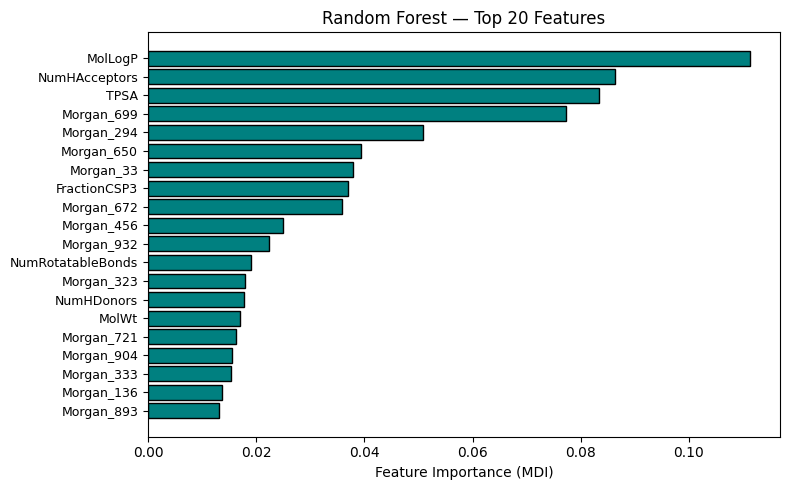

In [13]:
rf = RandomForestRegressor(n_estimators=200, max_features=0.3,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train.values, y_train)

top_n = 20
importances = rf.feature_importances_
idx = np.argsort(importances)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(top_n), importances[idx][::-1], color="teal", edgecolor="k")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in idx[::-1]], fontsize=9)
ax.set_xlabel("Feature Importance (MDI)")
ax.set_title("Random Forest — Top 20 Features")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Plot: Applicability domain scatter

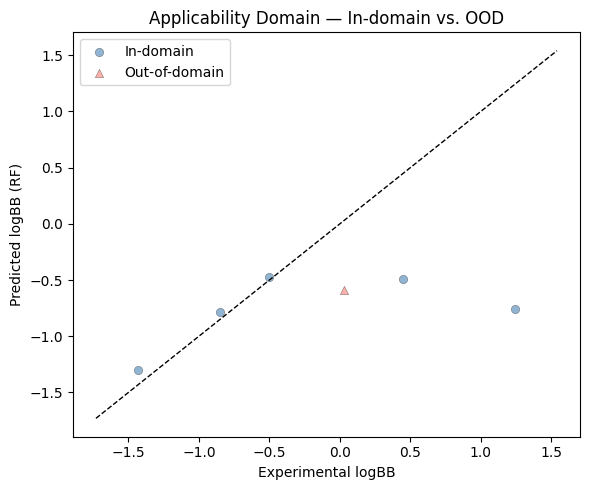

In [14]:
rf_preds = rf.predict(X_test.values)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test[in_domain],  rf_preds[in_domain],
           alpha=0.6, label="In-domain", color="steelblue", edgecolors="k", lw=0.3)
ax.scatter(y_test[~in_domain], rf_preds[~in_domain],
           alpha=0.6, label="Out-of-domain", color="salmon",
           marker="^", edgecolors="k", lw=0.3)
lo = min(y_test.min(), rf_preds.min()) - 0.3
hi = max(y_test.max(), rf_preds.max()) + 0.3
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlabel("Experimental logBB")
ax.set_ylabel("Predicted logBB (RF)")
ax.set_title("Applicability Domain — In-domain vs. OOD")
ax.legend()
plt.tight_layout()
plt.savefig("applicability_domain.png", dpi=150, bbox_inches="tight")
plt.show()

Final summary table

In [15]:
print("=" * 55)
print("  FINAL MODEL COMPARISON")
print("=" * 55)
print(results_df.to_string(index=False))
print()
print(f"Noise floor  →  RMSE={noise_rmse:.3f}  |  R²={noise_r2:.3f}")
best = results_df.loc[results_df["R²"].idxmax()]
print(f"Best model   →  {best['Model']}  (R²={best['R²']}, RMSE={best['RMSE']})")
print(f"OOD flagged  →  {(~in_domain).sum()} / {len(in_domain)} "
      f"({100*(~in_domain).mean():.1f}%) test compounds")

results_df.to_csv("model_results.csv", index=False)
print("\nSaved: model_results.csv")

  FINAL MODEL COMPARISON
            Model     R²  RMSE   MAE
 Ridge Regression -0.941 1.216 0.992
    Random Forest -0.157 0.939 0.630
Gradient Boosting -0.328 1.006 0.757

Noise floor  →  RMSE=0.288  |  R²=0.882
Best model   →  Random Forest  (R²=-0.157, RMSE=0.939)
OOD flagged  →  1 / 6 (16.7%) test compounds

Saved: model_results.csv
